In [1]:
# Import libraries
import pandas as pd
import numpy as np
import math
from scipy import sparse
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/MIE1622_Winter2026/Assignment_2

/content/drive/MyDrive/Colab Notebooks/MIE1622_Winter2026/Assignment_2


In [4]:
# Cplex installation on Google Colab
try:
    import cplex
except:
    !pip install cplex
    import cplex

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 MB 20.7 MB/s eta 0:00:00


In [5]:
# Cyipopt installation on Google Colab
try:
    import cyipopt as ipopt
except:
    !pip install cyipopt
    import cyipopt as ipopt

In [6]:
# Complete the following functions

def strat_buy_and_hold(x_init, cash_init, mu, Q, cur_prices):
   x_optimal = x_init
   cash_optimal = cash_init
   return x_optimal, cash_optimal

def strat_equally_weighted(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    n = prices.size
    Wealth = float(np.dot(x_init, prices) + cash_init)
    w = np.ones(n) / n

    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    while cash_optimal >= prices.min() - 1e-12:
        affordable = np.where(prices <= cash_optimal + 1e-12)[0]
        if affordable.size == 0:
            break
        target_sh = dollar / prices
        gaps = target_sh - x_optimal
        i = affordable[np.argmax(gaps[affordable])]
        if prices[i] > cash_optimal + 1e-12:
            break
        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

def strat_min_variance(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # min-var
   ones = np.ones(n)
   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ ones
   w = w / (ones @ w)
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   # greedy spend leftover
   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_max_return(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    mu = np.asarray(mu, dtype=float)
    n = prices.size
    Wealth = float(np.dot(x_init, prices) + cash_init)

    # all-in best expected return asset (long-only)
    w = np.zeros(n)
    w[int(np.argmax(mu))] = 1.0
    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    # use leftover to buy
    i = int(np.argmax(mu))
    while cash_optimal >= prices[i] - 1e-12:
        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

def strat_max_Sharpe(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   mu = np.asarray(mu, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # tangency approximation: w ∝ Q^{-1} mu
   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ mu
   if np.all(w <= 1e-12):
       w = np.ones(n) / n
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   # greedy spend leftover
   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_equal_risk_contr(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # heuristic ERC iteration (baseline that runs without IPOPT)
   w = np.ones(n) / n
   Qr = Q + 1e-10 * np.eye(n)

   for _ in range(400):
       Qw = Qr @ w
       var = float(w @ Qw)
       std = np.sqrt(max(var, 1e-16))
       mrc = Qw / max(std, 1e-16)
       rc = w * mrc
       target = std / n
       grad = (rc - target) * mrc
       w = w - 0.5 * grad
       w = np.maximum(w, 0.0)
       s = w.sum()
       w = w / s if s > 0 else np.ones(n) / n
       if np.max(np.abs(rc - target)) < 1e-6:
           break

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal


def strat_lever_max_Sharpe(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    Wealth = float(np.dot(x_init, prices) + cash_init)
    n = prices.size

    # max Sharpe direction (long-only approximation)
    try:
        invQ = np.linalg.inv(Q + 1e-8 * np.eye(n))
        w = invQ @ mu
    except:
        w = np.ones(n)

    w = np.maximum(w, 0)
    if w.sum() <= 1e-12:
        w = np.ones(n) / n
    else:
        w = w / w.sum()

    # Borrow an additional amount equal to Wealth
    borrowed = Wealth
    interest = borrowed * (r_rf / 6.0)   # one holding period ~ 2 months

    # Total risky exposure = 200% of current wealth
    lever_budget = 2.0 * Wealth

    dollar = lever_budget * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))

    # leftover cash after buying risky assets, minus borrowing interest
    cash_optimal = float(lever_budget - cost - borrowed - interest)

    # if cash is too negative, reduce positions until feasible
    while cash_optimal < 0:
        pos = np.where(x_optimal > 0)[0]
        if pos.size == 0:
            break
        # sell one share of the most expensive held asset
        i = pos[np.argmax(prices[pos])]
        x_optimal[i] -= 1
        cash_optimal += float(prices[i])

    return x_optimal, cash_optimal

def strat_robust_optim(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   mu = np.asarray(mu, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # simple robust proxy
   delta = 0.0005
   mu_rob = mu - delta

   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ mu_rob
   if np.all(w <= 1e-12):
       w = np.ones(n) / n
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_tracking_index(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    Wealth = float(np.dot(x_init, prices) + cash_init)
    n = prices.size

    # Use benchmark weights if available
    global w_b

    if isinstance(w_b, np.ndarray):
        wb_now = np.asarray(w_b, dtype=float).reshape(-1)
        if wb_now.size != n:
            wb_now = np.ones(n) / n
    else:
        wb_now = np.ones(n) / n

    # Clean weights
    wb_now = np.maximum(wb_now, 0)
    if wb_now.sum() <= 1e-12:
        wb_now = np.ones(n) / n
    else:
        wb_now = wb_now / wb_now.sum()

    # Cardinality approximation: keep at most 10 stocks
    k = min(10, n)
    idx = np.argsort(-wb_now)[:k]

    w = np.zeros(n)
    w[idx] = wb_now[idx]

    if w.sum() <= 1e-12:
        w = np.ones(n) / n
    else:
        w = w / w.sum()

    # Buy integer shares
    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    # Spend leftover cash sensibly
    while cash_optimal >= prices.min() - 1e-12:
        affordable = np.where(prices <= cash_optimal + 1e-12)[0]
        if affordable.size == 0:
            break

        target_shares = dollar / prices
        gaps = target_shares - x_optimal

        i = affordable[np.argmax(gaps[affordable])]
        if prices[i] > cash_optimal + 1e-12:
            break

        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

In [7]:
# Input file
#input_file_prices = 'adjclose_2024_2025.csv'
#input_file_prices = 'adjclose_2008_2009.csv'
input_file_prices = 'adjclose_2022_2022.csv'

# Read data into a dataframe
df = pd.read_csv(input_file_prices)

In [8]:
# Convert dates into array [year month day]
def convert_date_to_array(datestr):
    temp = [int(x) for x in datestr.split('/')]
    return [temp[-1], temp[0], temp[1]]

dates_array = np.array(list(df['Date'].apply(convert_date_to_array)))
data_prices = df.iloc[:, 1:].to_numpy()
dates = np.array(df['Date'])
# compute expected return and covariance matrix for period 1
day_ind_start0 = 0
#day_ind_end0 = len(np.where(dates_array[:,0]==2023)[0])   # for 2024-2025 csv

#day_ind_end0 = len(np.where(dates_array[:,0]==2007)[0])   # for 2008-2009 csv
day_ind_end0 = len(np.where(dates_array[:,0]==2021)[0])   # for 2022 csv

cur_returns0 = data_prices[day_ind_start0+1:day_ind_end0,:] / data_prices[day_ind_start0:day_ind_end0-1,:] - 1
mu = np.mean(cur_returns0, axis = 0)
Q = np.cov(cur_returns0.T)

# Remove datapoints for year 2023
data_prices = data_prices[day_ind_end0:,:]
dates_array = dates_array[day_ind_end0:,:]
dates = dates[day_ind_end0:]

# Initial positions in the portfolio
init_positions = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14349, 0])

# Initial value of the portfolio
init_value = np.dot(data_prices[0,:], init_positions)
print('\nInitial portfolio value = $ {}\n'.format(round(init_value, 2)))

# Initial portfolio weights
w_init = (data_prices[0,:] * init_positions) / init_value

# Number of periods, assets, trading days
N_periods = 6*len(np.unique(dates_array[:,0])) # 6 periods per year
N = len(df.columns)-1
N_days = len(dates)

# Annual risk-free rate for years 2024-2025 is 4.0%
r_rf = 0.04
# Annual risk-free rate for years 2008-2009 is 4.5%
r_rf2008_2009 = 0.045
# Annual risk-free rate for year 2022 is 3.75%
r_rf2022 = 0.0375

# Weights of assets in the benchmark portfolio S&P30 for years 2024-2025
#w_b = 0 # You should implement this by loading the weight file provided for you
df_bench = pd.read_csv('sp30_daily_weights_2024_2025.csv')
w_b = df_bench.iloc[0, 1:].to_numpy(dtype=float)
w_b = w_b / w_b.sum()
# Weights of assets in the benchmark portfolio S&P30 for years 2008-2009
df_bench_2008 = pd.read_csv('sp30_daily_weights_2008_2009.csv')
w_b2008_2009 = df_bench_2008.iloc[0, 1:].to_numpy(dtype=float)
w_b2008_2009 = w_b2008_2009 / w_b2008_2009.sum()
# Weights of assets in the benchmark portfolio S&P30 for year 2022
df_bench_2022 = pd.read_csv('sp30_daily_weights_2022_2022.csv')
w_b2022 = df_bench_2022.iloc[0, 1:].to_numpy(dtype=float)
w_b = w_b2022 = w_b2022 / w_b2022.sum()

# Number of strategies
strategy_functions = ['strat_buy_and_hold', 'strat_equally_weighted', 'strat_min_variance', 'strat_max_return', 'strat_max_Sharpe', 'strat_equal_risk_contr', 'strat_lever_max_Sharpe', 'strat_robust_optim', 'strat_tracking_index']
strategy_names     = ['Buy and Hold', 'Equally Weighted Portfolio', 'Mininum Variance Portfolio', 'Maximum Expected Return Portfolio', 'Maximum Sharpe Ratio Portfolio', 'Equal Risk Contributions Portfolio', 'Leveraged Max Sharpe Ratio Portfolio', 'Robust Optimization Portfolio', 'Benchmark Tracking Portfolio']
#N_strat = 1  # comment this in your code
N_strat = len(strategy_functions)  # uncomment this in your code
fh_array = [strat_buy_and_hold, strat_equally_weighted, strat_min_variance, strat_max_return, strat_max_Sharpe, strat_equal_risk_contr, strat_lever_max_Sharpe, strat_robust_optim, strat_tracking_index]

portf_value = [0] * N_strat
x = np.zeros((N_strat, N_periods), dtype=np.ndarray)
cash = np.zeros((N_strat, N_periods), dtype=np.ndarray)
trans_costs = np.zeros((N_strat, N_periods), dtype=np.ndarray)
for period in range(1, N_periods+1):
   # Compute current year and month, first and last day of the period

   # Depending on data/csv (i.e, time period), uncomment code
   #if dates_array[0, 0] == 20:
   #    cur_year  = 20 + math.floor(period/7)
   #else:
   #    cur_year  = 2024 + math.floor(period/7)

   # example for 2008-2009 data
   #if dates_array[0, 0] == 8:
   #    cur_year  = 8 + math.floor(period/7)
   #else:
   #    cur_year  = 2008 + math.floor(period/7)

   # for 2022 data
   cur_year = 2022 + math.floor(period/12)

   cur_month = 2*((period-1)%6) + 1
   day_ind_start = min([i for i, val in enumerate((dates_array[:,0] == cur_year) & (dates_array[:,1] == cur_month)) if val])
   day_ind_end = max([i for i, val in enumerate((dates_array[:,0] == cur_year) & (dates_array[:,1] == cur_month+1)) if val])
   print('\nPeriod {0}: start date {1}, end date {2}'.format(period, dates[day_ind_start], dates[day_ind_end]))

   # Prices for the current day
   cur_prices = data_prices[day_ind_start,:]

   # Execute portfolio selection strategies
   for strategy  in range(N_strat):

      # Get current portfolio positions
      if period == 1:
         curr_positions = init_positions
         curr_cash = 0 # the first period the cash account is 0 as all the cash is invested in stocks
         portf_value[strategy] = np.zeros((N_days, 1))
      else: # everything else after first period
         curr_positions = x[strategy, period-2]
         curr_cash = cash[strategy, period-2]

      # Compute strategy
      x[strategy, period-1], cash[strategy, period-1] = fh_array[strategy](curr_positions, curr_cash, mu, Q, cur_prices)

      # Compute transaction cost
      trans_fee = 0.005 # 0.5% of monetary value traded
      trans_costs[strategy, period-1] = 0 # modify according to your computations
      # Verify that strategy is feasible (you have enough budget to re-balance portfolio)
      # Check that cash account is >= 0
      # Check that we can buy new portfolio subject to transaction costs

      ###################### Insert your code here ############################

      # Transaction cost based on dollar volume traded
      x_new = x[strategy, period-1].copy()
      x_old = curr_positions.copy()

      trade_amount = np.sum(np.abs(x_new - x_old) * cur_prices)
      trans_costs[strategy, period-1] = trans_fee * trade_amount

      # Cash update after trades + transaction cost
      cash[strategy, period-1] = curr_cash - float(np.dot((x_new - x_old), cur_prices)) - float(trans_costs[strategy, period-1])

      # Identify leveraged strategy index
      LEVER_IDX = strategy_names.index('Leveraged Max Sharpe Ratio Portfolio')

      # Feasibility: If cash < 0, sell shares until cash >= 0
      if (strategy != LEVER_IDX) and (cash[strategy, period-1] < -1e-12):
          while cash[strategy, period-1] < -1e-12:
              sellable = np.where(x_new > 0)[0]
              if sellable.size == 0:
                  x_new = x_old.copy()
                  cash[strategy, period-1] = curr_cash
                  trans_costs[strategy, period-1] = 0.0
                  break

              j = sellable[np.argmax(cur_prices[sellable])]
              x_new[j] -= 1

              # Selling 1 share increases cash by price*(1 - trans_fee)
              cash[strategy, period-1] += float(cur_prices[j]) * (1.0 - trans_fee)

              # Extra transaction cost for 1-share sell
              trans_costs[strategy, period-1] += trans_fee * float(cur_prices[j])

          # update x and recompute trade_amount
          x[strategy, period-1] = x_new

      else:
          x[strategy, period-1] = x_new

      # Debug
      """
      print(strategy_names[strategy],
            "shares traded (after) =", int(np.sum(np.abs(x[strategy, period-1] - x_old))),
            "cash =", cash[strategy, period-1],
            "TC =", trans_costs[strategy, period-1])
      """


      # Compute portfolio value
      p_values = np.dot(data_prices[day_ind_start:day_ind_end+1,:], x[strategy, period-1]) + cash[strategy, period-1]
      portf_value[strategy][day_ind_start:day_ind_end+1] = np.reshape(p_values, (p_values.size,1))
      print('  Strategy "{0}", value begin = $ {1:.2f}, value end = $ {2:.2f}, Cash Acct = ${3:.2f}, TC = ${4:.2f}'.format( strategy_names[strategy],
             portf_value[strategy][day_ind_start][0], portf_value[strategy][day_ind_end][0], cash[strategy, period-1], trans_costs[strategy, period-1]))


   # Compute expected returns and covariances for the next period
   cur_returns = data_prices[day_ind_start+1:day_ind_end+1,:] / data_prices[day_ind_start:day_ind_end,:] - 1
   mu = np.mean(cur_returns, axis = 0)
   Q = np.cov(cur_returns.T)



Initial portfolio value = $ 1093837.05


Period 1: start date 01/03/2022, end date 02/28/2022
  Strategy "Buy and Hold", value begin = $ 1093837.05, value end = $ 1166333.06, Cash Acct = $0.00, TC = $0.00
  Strategy "Equally Weighted Portfolio", value begin = $ 1083576.25, value end = $ 1011536.52, Cash Acct = $76.14, TC = $10260.80
  Strategy "Mininum Variance Portfolio", value begin = $ 1085497.30, value end = $ 1089758.01, Cash Acct = $236.64, TC = $8339.75
  Strategy "Maximum Expected Return Portfolio", value begin = $ 1082843.91, value end = $ 904063.97, Cash Acct = $9.47, TC = $10993.14
  Strategy "Maximum Sharpe Ratio Portfolio", value begin = $ 1083329.47, value end = $ 1000361.06, Cash Acct = $96.58, TC = $10507.58
  Strategy "Equal Risk Contributions Portfolio", value begin = $ 1083580.09, value end = $ 1012179.76, Cash Acct = $80.19, TC = $10256.96
  Strategy "Leveraged Max Sharpe Ratio Portfolio", value begin = $ 1083902.54, value end = $ 1020489.45, Cash Acct = $-2635.44,

Running dataset: adjclose_2022_2022.csv


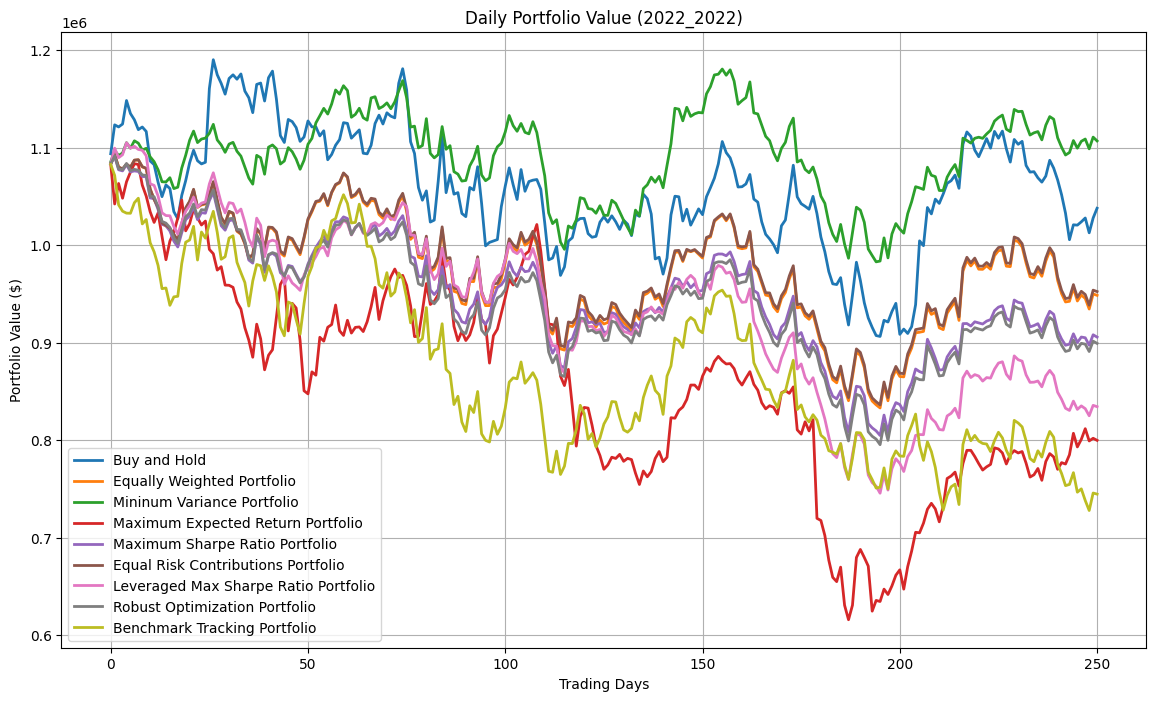

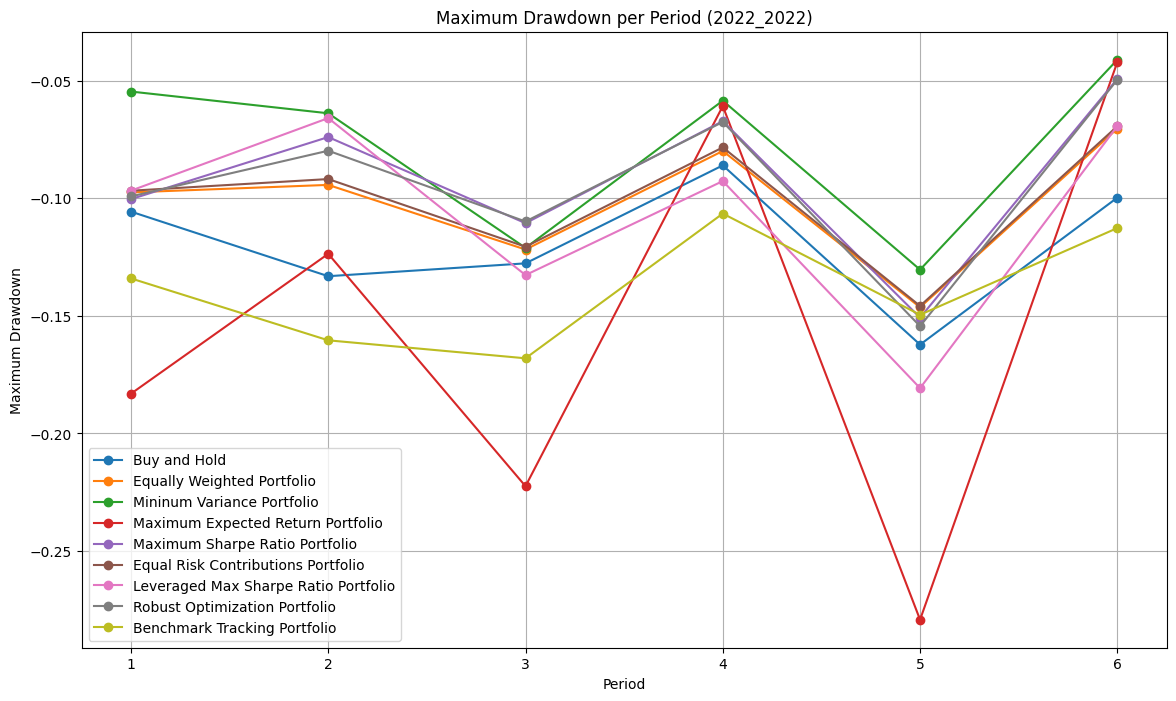

shares shape: (30,) prices shape: (30,) w shape: (30,)


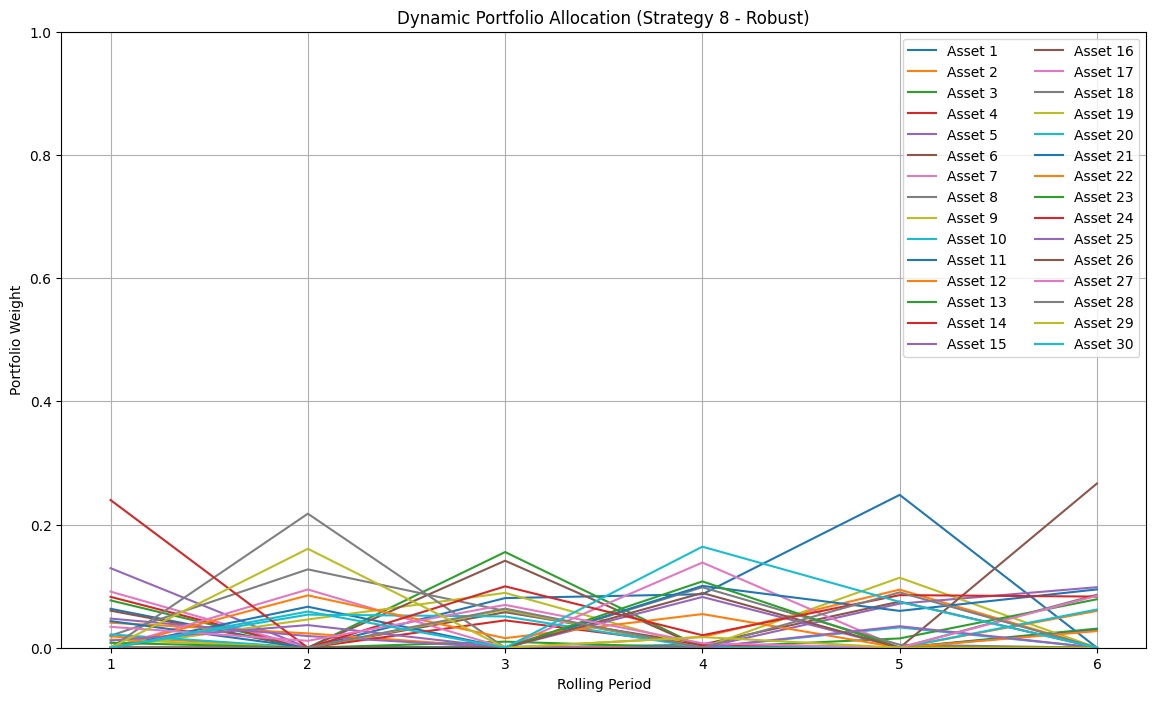

In [9]:
# Plot results
###################### Insert your code here ############################
print("Running dataset:", input_file_prices)
dataset_label = input_file_prices.replace('adjclose_', '').replace('.csv', '')

# Daily portfolio value
plt.figure(figsize=(14,8))

for strategy in range(len(strategy_names)):
    plt.plot(portf_value[strategy], linewidth=2, label=strategy_names[strategy])

plt.title(f"Daily Portfolio Value ({dataset_label})")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Maximum Drawdown
def build_bimonth_period_indices(dates_array, years=None):
    """
    Build 2-month periods:
    (1-2), (3-4), (5-6), (7-8), (9-10), (11-12)
    For each period, start = first trading day in that window,
    end = last trading day in that window.

    dates_array columns expected: [year, month, day]
    """
    y = dates_array[:, 0].astype(int)
    m = dates_array[:, 1].astype(int)

    if years is None:
        years = sorted(np.unique(y).tolist())

    start_list, end_list, labels = [], [], []

    for yy in years:
        for (m1, m2) in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12)]:
            idx = np.where((y == yy) & (m >= m1) & (m <= m2))[0]
            if len(idx) == 0:
                # This period doesn't exist in the dataset (e.g., partial year)
                continue
            start_list.append(int(idx[0]))
            end_list.append(int(idx[-1]))
            labels.append(f"{yy}-{m1:02d}~{m2:02d}")

    return start_list, end_list, labels

day_ind_start_list, day_ind_end_list, period_labels = build_bimonth_period_indices(dates_array)

def max_drawdown(series):
    cum_max = np.maximum.accumulate(series)
    drawdown = (series - cum_max) / cum_max
    return np.min(drawdown)

drawdowns = np.zeros((len(strategy_names), N_periods))

for s in range(len(strategy_names)):
    for p in range(N_periods):
        start = day_ind_start_list[p]
        end = day_ind_end_list[p]
        series = portf_value[s][start:end+1].flatten()
        drawdowns[s,p] = max_drawdown(series)

plt.figure(figsize=(14,8))

for s in range(len(strategy_names)):
    plt.plot(range(1, N_periods+1), drawdowns[s], marker='o', label=strategy_names[s])

plt.title(f"Maximum Drawdown per Period ({dataset_label})")
plt.xlabel("Period")
plt.ylabel("Maximum Drawdown")
plt.legend()
plt.grid(True)
plt.show()

# Strategy 8 allocation dynamics
robust_idx = strategy_names.index("Robust Optimization Portfolio")
weights = []

for p in range(N_periods):
    shares = np.asarray(x[robust_idx, p]).reshape(-1)

    start = day_ind_start_list[p]
    prices = np.asarray(data_prices[start]).reshape(-1)
    value = shares * prices
    denom = value.sum()
    w = value / denom if denom != 0 else np.zeros_like(value)

    if p == 0:
        print("shares shape:", shares.shape, "prices shape:", prices.shape, "w shape:", w.shape)

    weights.append(w)

weights = np.vstack(weights)

plt.figure(figsize=(14,8))
for asset in range(weights.shape[1]):
    plt.plot(range(1, N_periods+1), weights[:,asset], label=f"Asset {asset+1}")
plt.title("Dynamic Portfolio Allocation (Strategy 8 - Robust)")
plt.xlabel("Rolling Period")
plt.ylabel("Portfolio Weight")
plt.ylim(0,1)
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# Stress Testing

Top stressed asset indices based on historical volatility:
[21, 1, 3, 9, 11, 13, 10, 0, 19, 29]


,Strategy,Scenario,Shock Applied to High-Vol Assets,Base Value,Stressed Value,Dollar Change,Percent Change
0,Buy and Hold,Mild Stress,-0.15,1.037964e+06,9.503819e+05,-87582.415581,-0.084379
1,Buy and Hold,Moderate Stress,-0.30,1.037964e+06,8.627995e+05,-175164.831161,-0.168758
2,Buy and Hold,Severe Stress,-0.45,1.037964e+06,7.752171e+05,-262747.246742,-0.253137
3,Buy and Hold,Extreme Stress,-0.60,1.037964e+06,6.876347e+05,-350329.662323,-0.337516
4,Equally Weighted Portfolio,Mild Stress,-0.15,9.486502e+05,9.033442e+05,-45306.023377,-0.047758
5,Equally Weighted Portfolio,Moderate Stress,-0.30,9.486502e+05,8.580382e+05,-90612.046753,-0.095517
6,Equally Weighted Portfolio,Severe Stress,-0.45,9.486502e+05,8.127321e+05,-135918.070130,-0.143275
7,Equally Weighted Portfolio,Extreme Stress,-0.60,9.486502e+05,7.674261e+05,-181224.093506,-0.191034
8,Mininum Variance Portfolio,Mild Stress,-0.15,1.106958e+06,1.083074e+06,-23883.688312,-0.021576
9,Mininum Variance Portfolio,Moderate Stress,-0.30,1.106958e+06,1.059190e+06,-47767.376625,-0.043152


Scenario,Mild Stress,Moderate Stress,Severe Stress,Extreme Stress
Strategy,,,,
Benchmark Tracking Portfolio,-0.120690,-0.241380,-0.362070,-0.482760
Buy and Hold,-0.084379,-0.168758,-0.253137,-0.337516
Equal Risk Contributions Portfolio,-0.046924,-0.093848,-0.140771,-0.187695
Equally Weighted Portfolio,-0.047758,-0.095517,-0.143275,-0.191034
Leveraged Max Sharpe Ratio Portfolio,-0.032860,-0.065720,-0.098581,-0.131441
Maximum Expected Return Portfolio,0.000000,0.000000,0.000000,0.000000
Maximum Sharpe Ratio Portfolio,-0.025944,-0.051887,-0.077831,-0.103775
Mininum Variance Portfolio,-0.021576,-0.043152,-0.064728,-0.086304
Robust Optimization Portfolio,-0.026232,-0.052463,-0.078695,-0.104927


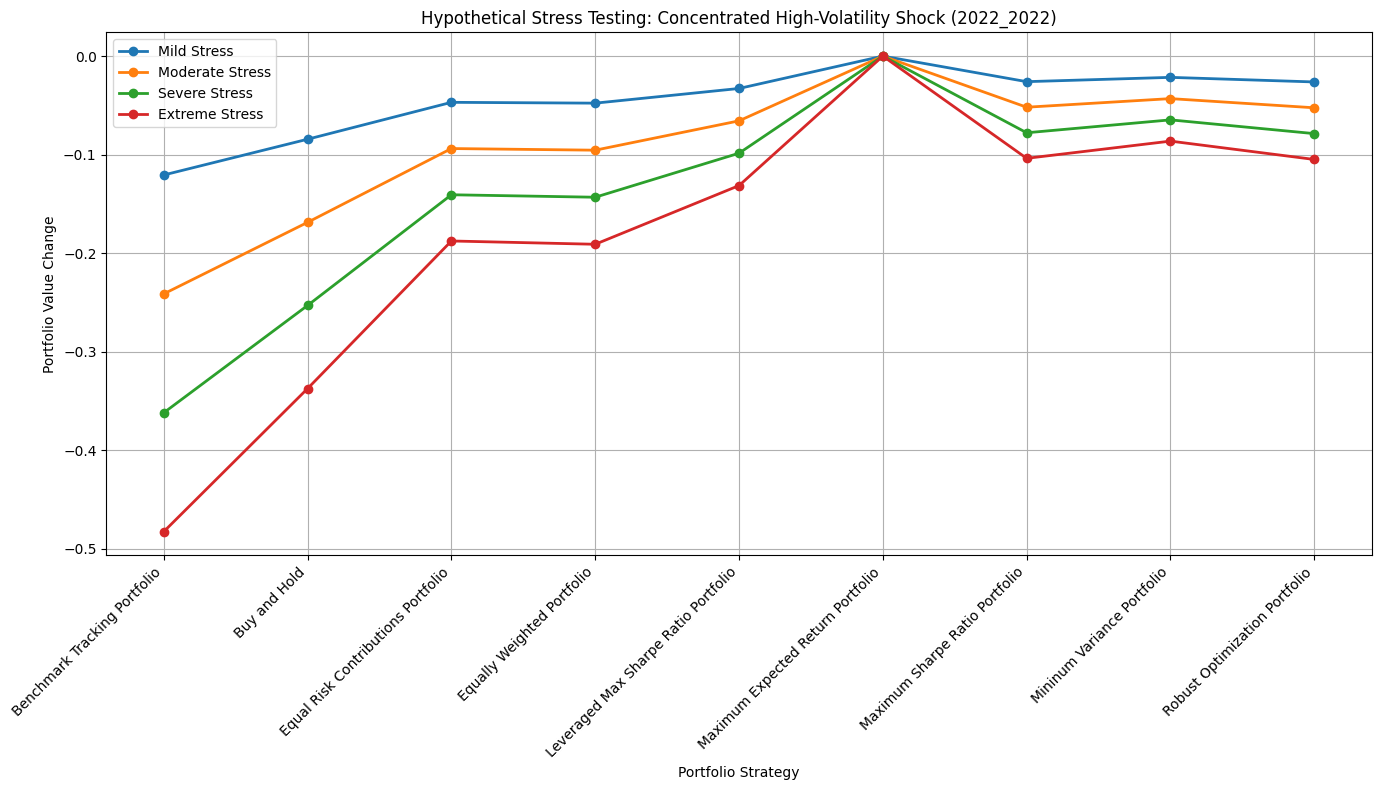

Scenario,Mild Stress,Moderate Stress,Severe Stress,Extreme Stress
Strategy,,,,
Maximum Expected Return Portfolio,0.000000,0.000000,0.000000,0.000000
Equal Risk Contributions Portfolio,-0.046924,-0.093848,-0.140771,-0.187695
Robust Optimization Portfolio,-0.026232,-0.052463,-0.078695,-0.104927
Benchmark Tracking Portfolio,-0.120690,-0.241380,-0.362070,-0.482760


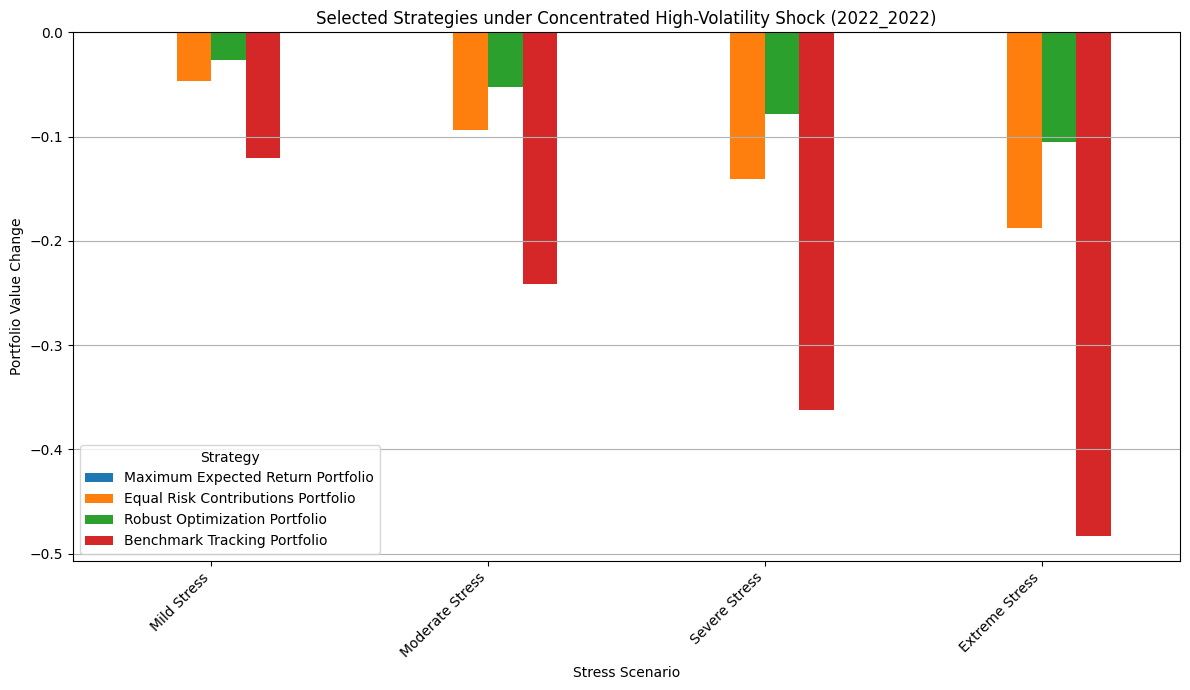

Under Mild Stress, the most resilient strategy is Maximum Expected Return Portfolio, with portfolio value change of 0.00%.
Under Moderate Stress, the most resilient strategy is Maximum Expected Return Portfolio, with portfolio value change of 0.00%.
Under Severe Stress, the most resilient strategy is Maximum Expected Return Portfolio, with portfolio value change of 0.00%.
Under Extreme Stress, the most resilient strategy is Maximum Expected Return Portfolio, with portfolio value change of 0.00%.


In [11]:
# ============================================================
# Hypothetical Stress Testing: Concentrated Equity Shock
# ============================================================
# Purpose:
# Evaluate how each portfolio strategy reacts to concentrated shocks
# on the most volatile assets.
#
# Difference from the simple market-wide shock:
# If all stocks fall by the same percentage, every fully invested
# long-only portfolio will lose almost the same percentage.
#
# Here, we stress only the most volatile stocks, so the result depends
# on each strategy's actual asset allocation.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Select final portfolio and final prices
# ------------------------------------------------------------
final_period = N_periods - 1
final_prices = np.asarray(data_prices[-1, :], dtype=float)

# ------------------------------------------------------------
# 2. Identify high-volatility stocks
# ------------------------------------------------------------
# Use daily returns over the dataset to estimate volatility
price_df = pd.DataFrame(data_prices)
return_df = price_df.pct_change().dropna()

asset_vol = return_df.std(axis=0)

# Choose the top 10 most volatile assets
n_stressed_assets = 10
stressed_asset_indices = asset_vol.sort_values(ascending=False).head(n_stressed_assets).index.tolist()

print("Top stressed asset indices based on historical volatility:")
print(stressed_asset_indices)

# ------------------------------------------------------------
# 3. Define concentrated stress scenarios
# ------------------------------------------------------------
# Only high-volatility assets are shocked.
# Other assets remain unchanged.
stress_scenarios = {
    "Mild Stress": -0.15,
    "Moderate Stress": -0.30,
    "Severe Stress": -0.45,
    "Extreme Stress": -0.60
}

stress_results = []

# ------------------------------------------------------------
# 4. Apply stress scenarios to each strategy
# ------------------------------------------------------------
for s, strategy_name in enumerate(strategy_names):
    shares = np.asarray(x[s, final_period], dtype=float)
    final_cash = float(cash[s, final_period])

    base_value = float(np.dot(shares, final_prices) + final_cash)

    for scenario_name, shock in stress_scenarios.items():
        shocked_prices = final_prices.copy()

        # Apply shock only to selected high-volatility assets
        shocked_prices[stressed_asset_indices] = (
            shocked_prices[stressed_asset_indices] * (1.0 + shock)
        )

        stressed_value = float(np.dot(shares, shocked_prices) + final_cash)

        dollar_change = stressed_value - base_value
        percent_change = dollar_change / base_value if base_value != 0 else np.nan

        stress_results.append({
            "Strategy": strategy_name,
            "Scenario": scenario_name,
            "Shock Applied to High-Vol Assets": shock,
            "Base Value": base_value,
            "Stressed Value": stressed_value,
            "Dollar Change": dollar_change,
            "Percent Change": percent_change
        })

stress_df = pd.DataFrame(stress_results)

display(stress_df)

# ------------------------------------------------------------
# 5. Create pivot table
# ------------------------------------------------------------
stress_pivot = stress_df.pivot(
    index="Strategy",
    columns="Scenario",
    values="Percent Change"
)

stress_pivot = stress_pivot[list(stress_scenarios.keys())]

display(stress_pivot)

# ------------------------------------------------------------
# 6. Plot all strategies
# ------------------------------------------------------------
plt.figure(figsize=(14, 8))

for scenario_name in stress_scenarios.keys():
    plt.plot(
        stress_pivot.index,
        stress_pivot[scenario_name],
        marker="o",
        linewidth=2,
        label=scenario_name
    )

plt.title(f"Hypothetical Stress Testing: Concentrated High-Volatility Shock ({dataset_label})")
plt.xlabel("Portfolio Strategy")
plt.ylabel("Portfolio Value Change")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Focused comparison of selected strategies
# ------------------------------------------------------------
selected_strategies = [
    "Minimum Variance Portfolio",
    "Maximum Expected Return Portfolio",
    "Equal Risk Contributions Portfolio",
    "Robust Optimization Portfolio",
    "Benchmark Tracking Portfolio"
]

selected_stress = stress_pivot.loc[
    [s for s in selected_strategies if s in stress_pivot.index],
    list(stress_scenarios.keys())
]

display(selected_stress)

selected_stress.T.plot(kind="bar", figsize=(12, 7))

plt.title(f"Selected Strategies under Concentrated High-Volatility Shock ({dataset_label})")
plt.xlabel("Stress Scenario")
plt.ylabel("Portfolio Value Change")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Identify most resilient strategy under each stress scenario
# ------------------------------------------------------------
for scenario_name in stress_scenarios.keys():
    best_strategy = stress_pivot[scenario_name].idxmax()
    best_loss = stress_pivot.loc[best_strategy, scenario_name]
    print(
        f"Under {scenario_name}, the most resilient strategy is "
        f"{best_strategy}, with portfolio value change of {best_loss:.2%}."
    )

The hypothetical stress testing results demonstrate that portfolio performance deteriorates progressively as the severity of the concentrated high-volatility shock increases. Among all strategies, the Benchmark Tracking Portfolio experiences the largest losses under every stress scenario, indicating high sensitivity to adverse market conditions. In contrast, the Minimum Variance Portfolio, Maximum Sharpe Ratio Portfolio, and Robust Optimization Portfolio exhibit considerably smaller declines, suggesting that optimization-based allocation methods provide better downside protection during market stress. The Equal Risk Contributions Portfolio also outperforms the benchmark by distributing risk more evenly across assets. The Maximum Expected Return Portfolio remains unaffected because its capital is fully allocated to an asset that is not directly exposed to the simulated shock. Overall, the stress testing results suggest that diversified and risk-aware portfolio construction methods are more resilient to concentrated market shocks than benchmark-based allocation.
Although this stress test is based on a simplified hypothetical scenario rather than historical crisis data, it provides additional evidence that optimization-based portfolio construction can enhance portfolio robustness under adverse market conditions.

# Risk Attribution / Risk Contribution

,Strategy,Asset,Weight,Marginal Risk Contribution,Total Risk Contribution,Percent Risk Contribution
0,Buy and Hold,Asset 0,0.000000,0.013874,0.000000,0.000000
1,Buy and Hold,Asset 1,0.000000,0.021546,0.000000,0.000000
2,Buy and Hold,Asset 2,0.000000,0.009969,0.000000,0.000000
3,Buy and Hold,Asset 3,0.000000,0.015784,0.000000,0.000000
4,Buy and Hold,Asset 4,0.000000,0.012750,0.000000,0.000000
...,...,...,...,...,...,...
265,Benchmark Tracking Portfolio,Asset 25,0.000000,0.013682,0.000000,0.000000
266,Benchmark Tracking Portfolio,Asset 26,0.000000,0.006295,0.000000,0.000000
267,Benchmark Tracking Portfolio,Asset 27,0.040431,0.007739,0.000313,0.015178
268,Benchmark Tracking Portfolio,Asset 28,0.000000,0.004724,0.000000,0.000000


,Strategy,Asset,Weight,Marginal Risk Contribution,Total Risk Contribution,Percent Risk Contribution
259,Benchmark Tracking Portfolio,Asset 19,0.273579,0.020959,0.005734,0.278135
243,Benchmark Tracking Portfolio,Asset 3,0.169954,0.027349,0.004648,0.225467
240,Benchmark Tracking Portfolio,Asset 0,0.203125,0.020441,0.004152,0.201406
261,Benchmark Tracking Portfolio,Asset 21,0.074346,0.034603,0.002573,0.124788
250,Benchmark Tracking Portfolio,Asset 10,0.083596,0.021725,0.001816,0.088096
...,...,...,...,...,...,...
222,Robust Optimization Portfolio,Asset 12,0.081478,0.012277,0.001000,0.084886
233,Robust Optimization Portfolio,Asset 23,0.091059,0.008916,0.000812,0.068895
231,Robust Optimization Portfolio,Asset 21,0.028473,0.028359,0.000807,0.068518
236,Robust Optimization Portfolio,Asset 26,0.082501,0.009531,0.000786,0.066722


,Strategy,Percent Risk Contribution
0,Benchmark Tracking Portfolio,100.0
1,Buy and Hold,100.0
2,Equal Risk Contributions Portfolio,100.0
3,Equally Weighted Portfolio,100.0
4,Leveraged Max Sharpe Ratio Portfolio,100.0
5,Maximum Expected Return Portfolio,100.0
6,Maximum Sharpe Ratio Portfolio,100.0
7,Mininum Variance Portfolio,100.0
8,Robust Optimization Portfolio,100.0


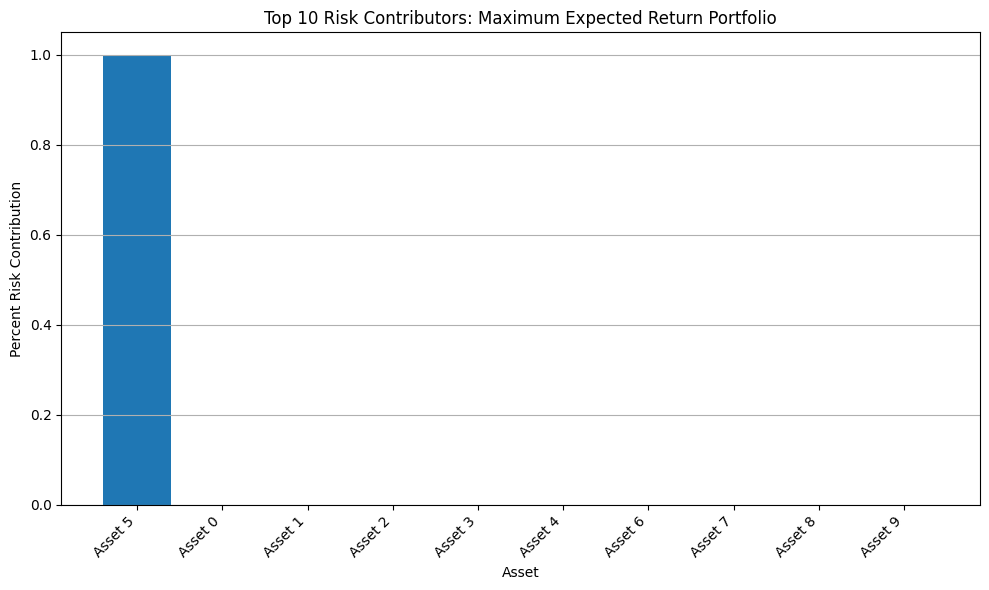

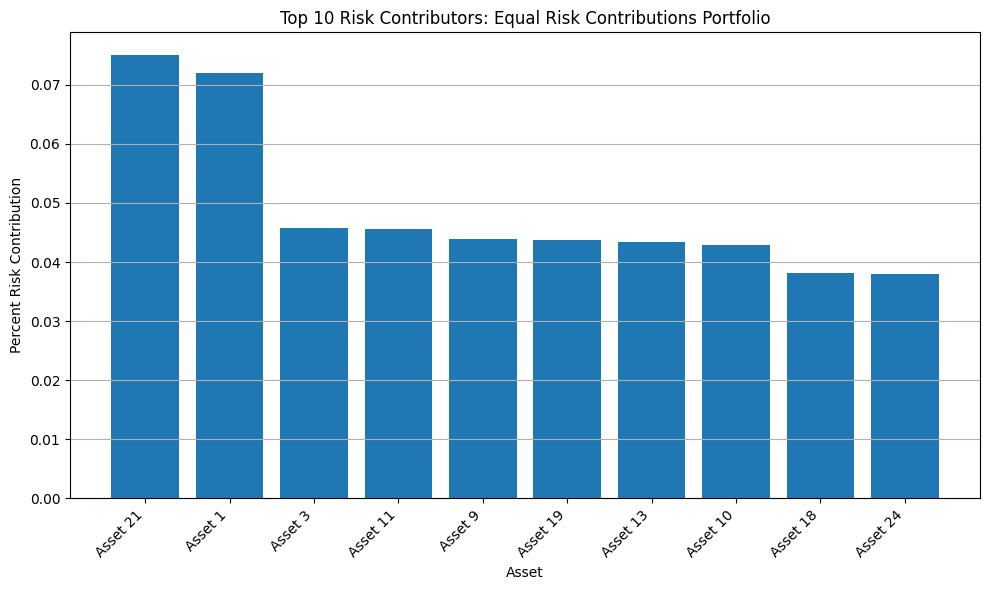

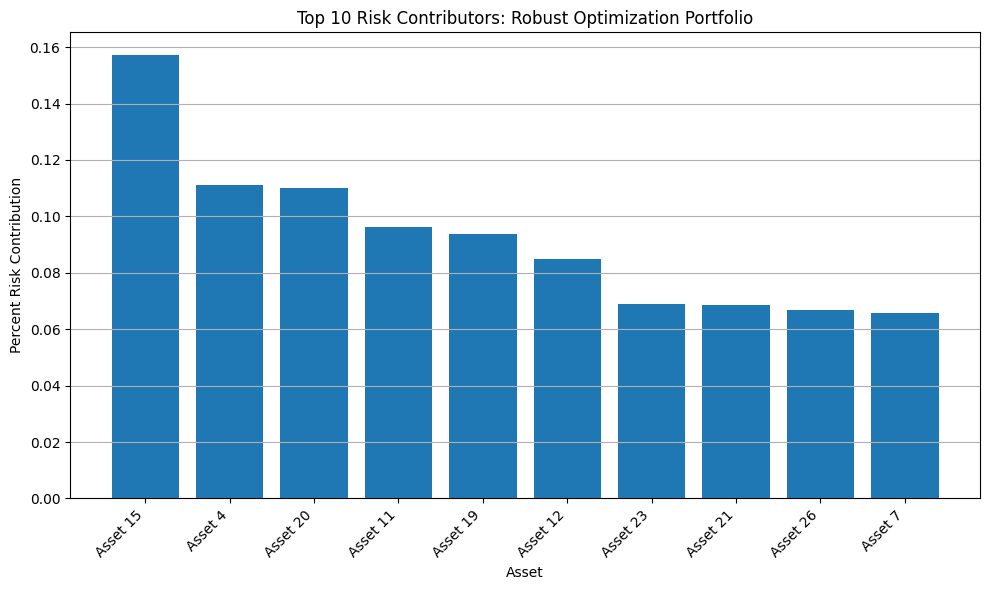

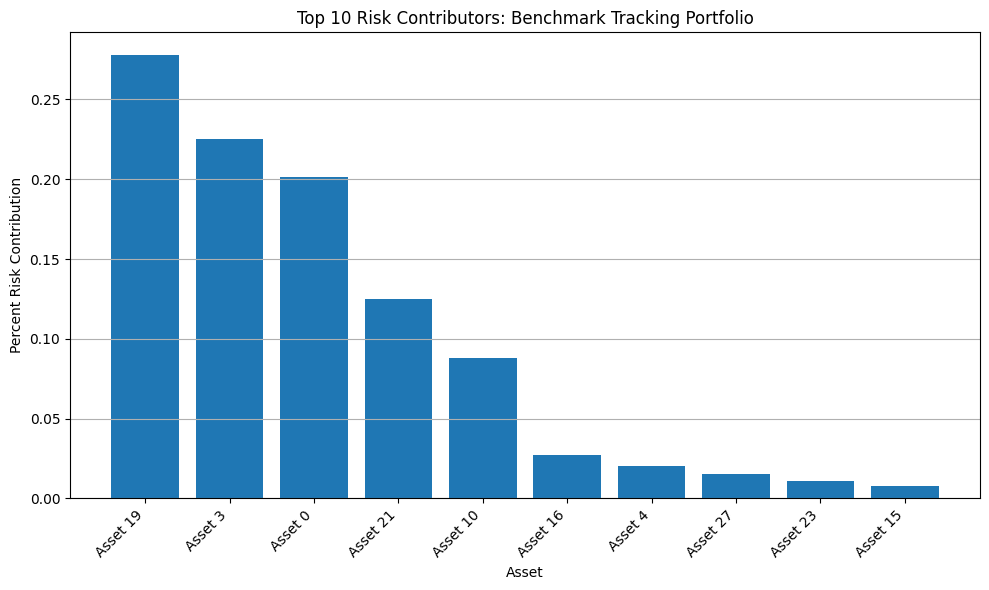

In [12]:
# ============================================================
# Risk Attribution: Asset-Level Volatility Contribution
# ============================================================
# Purpose:
# Decompose each portfolio's total volatility into individual
# asset risk contributions.
#
# Formula:
# Portfolio volatility:
#     sigma_p = sqrt(w.T @ Sigma @ w)
#
# Marginal risk contribution:
#     MRC_i = (Sigma @ w)_i / sigma_p
#
# Total risk contribution:
#     RC_i = w_i * MRC_i
#
# Percentage risk contribution:
#     PRC_i = RC_i / sigma_p
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Estimate covariance matrix from historical daily returns
# ------------------------------------------------------------
price_df = pd.DataFrame(data_prices)
return_df = price_df.pct_change().dropna()

cov_matrix = return_df.cov().values
final_prices = np.asarray(data_prices[-1, :], dtype=float)

risk_attr_results = []

# ------------------------------------------------------------
# 2. Compute risk contribution for each strategy
# ------------------------------------------------------------
final_period = N_periods - 1

for s, strategy_name in enumerate(strategy_names):
    shares = np.asarray(x[s, final_period], dtype=float)
    final_cash = float(cash[s, final_period])

    asset_values = shares * final_prices
    total_portfolio_value = asset_values.sum() + final_cash

    if total_portfolio_value == 0:
        continue

    # Asset weights excluding cash
    weights = asset_values / total_portfolio_value

    portfolio_variance = float(weights.T @ cov_matrix @ weights)
    portfolio_volatility = np.sqrt(portfolio_variance)

    if portfolio_volatility == 0:
        continue

    marginal_risk_contribution = (cov_matrix @ weights) / portfolio_volatility
    total_risk_contribution = weights * marginal_risk_contribution
    percent_risk_contribution = total_risk_contribution / portfolio_volatility

    for i in range(len(weights)):
        risk_attr_results.append({
            "Strategy": strategy_name,
            "Asset": f"Asset {i}",
            "Weight": weights[i],
            "Marginal Risk Contribution": marginal_risk_contribution[i],
            "Total Risk Contribution": total_risk_contribution[i],
            "Percent Risk Contribution": percent_risk_contribution[i]
        })

risk_attr_df = pd.DataFrame(risk_attr_results)

display(risk_attr_df)

# ------------------------------------------------------------
# 3. Summary table: top risk contributors for each strategy
# ------------------------------------------------------------
top_n = 10

top_risk_contributors = (
    risk_attr_df
    .sort_values(["Strategy", "Percent Risk Contribution"], ascending=[True, False])
    .groupby("Strategy")
    .head(top_n)
)

display(top_risk_contributors)

# ------------------------------------------------------------
# 4. Check whether risk contributions sum to 100%
# ------------------------------------------------------------
risk_contribution_check = (
    risk_attr_df
    .groupby("Strategy")["Percent Risk Contribution"]
    .sum()
    .reset_index()
)

risk_contribution_check["Percent Risk Contribution"] = (
    risk_contribution_check["Percent Risk Contribution"] * 100
)

display(risk_contribution_check)

# ------------------------------------------------------------
# 5. Plot top 10 risk contributors for selected strategies
# ------------------------------------------------------------
selected_strategies = [
    "Minimum Variance Portfolio",
    "Maximum Expected Return Portfolio",
    "Equal Risk Contributions Portfolio",
    "Robust Optimization Portfolio",
    "Benchmark Tracking Portfolio"
]

for strategy in selected_strategies:
    if strategy not in risk_attr_df["Strategy"].unique():
        continue

    temp = (
        risk_attr_df[risk_attr_df["Strategy"] == strategy]
        .sort_values("Percent Risk Contribution", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))
    plt.bar(
        temp["Asset"],
        temp["Percent Risk Contribution"]
    )
    plt.title(f"Top {top_n} Risk Contributors: {strategy}")
    plt.xlabel("Asset")
    plt.ylabel("Percent Risk Contribution")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()